In [1]:
# ENVIRONMENT FIX FOR KERAS 3
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [2]:
# LIBRARIES
import pandas as pd
import numpy as np
from rdkit import Chem
import deepchem as dc
from sklearn.metrics import classification_report

wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


In [3]:
# LOAD DATA
df = pd.read_csv('mtb_multi_target_bioactivity.csv')
df = df[df['Canonical SMILES'].notnull() & df['Standard Value'].notnull()]

def label_activity(row):
    try:
        val = float(row['Standard Value'])
        if 'nM' in row['Standard Units']:
            return 1 if val < 1000 else 0
        elif 'uM' in row['Standard Units']:
            return 1 if val < 1 else 0
    except:
        return 0

df['Activity'] = df.apply(label_activity, axis=1)

In [4]:
# MULTI-TARGET LABEL PIVOT
pivot = df.pivot_table(index='Canonical SMILES', columns='Target', values='Activity', aggfunc='max').fillna(0).astype(int)
pivot = pivot.loc[pivot.index.map(lambda smi: Chem.MolFromSmiles(smi) is not None)]

In [5]:
# FEATURIZATION
smiles = list(pivot.index)
labels = pivot.values
tasks = list(pivot.columns)

featurizer = dc.feat.ConvMolFeaturizer()
features = featurizer.featurize(smiles)

dataset = dc.data.NumpyDataset(features, labels)

Streaming output truncated to the last 5000 lines.
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[11:22:22] DEPRECATION WARNING: please use GetValence(getExplicit=False)


In [6]:
# SPLIT DATA
splitter = dc.splits.RandomSplitter()
train, valid, test = splitter.train_valid_test_split(dataset)

In [7]:
# DEFINE MODEL
model = dc.models.GraphConvModel(
    len(tasks), mode='classification',
    dropout=0.3, learning_rate=0.001,
    batch_size=64, model_dir='graphconv_model'
)

In [8]:
# TRAIN MODEL
model.fit(train, nb_epoch=30)

0.2859573173522949

In [9]:
# EVALUATE
metric = dc.metrics.Metric(dc.metrics.roc_auc_score, np.mean, mode='classification')
print("Train ROC-AUC:", model.evaluate(train, [metric]))
print("Valid ROC-AUC:", model.evaluate(valid, [metric]))
print("Test ROC-AUC:", model.evaluate(test, [metric]))

Train ROC-AUC: {'mean-roc_auc_score': np.float64(0.9110221267623156)}
Valid ROC-AUC: {'mean-roc_auc_score': np.float64(0.8858388704318937)}
Test ROC-AUC: {'mean-roc_auc_score': np.float64(0.9408653846153845)}


In [28]:
# Get only probability of class 1 (active)
y_prob = model.predict(test)[:, :, 1]

# Binarize at 0.5 threshold
y_pred = (y_prob > 0.5).astype(int)

# Ground truth
y_true = np.asarray(test.y, dtype=int)

In [29]:
# Confirm shape
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

y_true shape: (114, 10)
y_pred shape: (114, 10)


In [30]:
# Generate report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=tasks, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

       ClpC1       0.70      0.88      0.78        26
       DprE1       0.74      0.77      0.75        26
        FtsZ       0.69      0.85      0.76        26
        GyrB       0.66      0.81      0.72        26
        InhA       0.73      0.92      0.81        26
        KasA       0.68      0.88      0.77        26
        KatG       0.72      0.81      0.76        26
        PanK       0.67      0.85      0.75        26
        PknB       0.64      0.88      0.74        26
        RpoB       0.63      0.85      0.72        26

   micro avg       0.68      0.85      0.76       260
   macro avg       0.68      0.85      0.76       260
weighted avg       0.68      0.85      0.76       260
 samples avg       0.22      0.19      0.20       260



In [31]:
model.save_checkpoint()

In [32]:
import shutil

# Zip the graphconv_model folder
shutil.make_archive("graphconv_model", 'zip', "graphconv_model")

'/content/graphconv_model.zip'

In [33]:
import json

tasks = ['ClpC1', 'DprE1', 'FtsZ', 'GyrB', 'InhA', 'KasA', 'KatG', 'PanK', 'PknB', 'RpoB']
with open("task_list.json", "w") as f:
    json.dump(tasks, f)

In [34]:
import joblib
from deepchem.feat import ConvMolFeaturizer

featurizer = ConvMolFeaturizer()
joblib.dump(featurizer, "featurizer.pkl")

['featurizer.pkl']

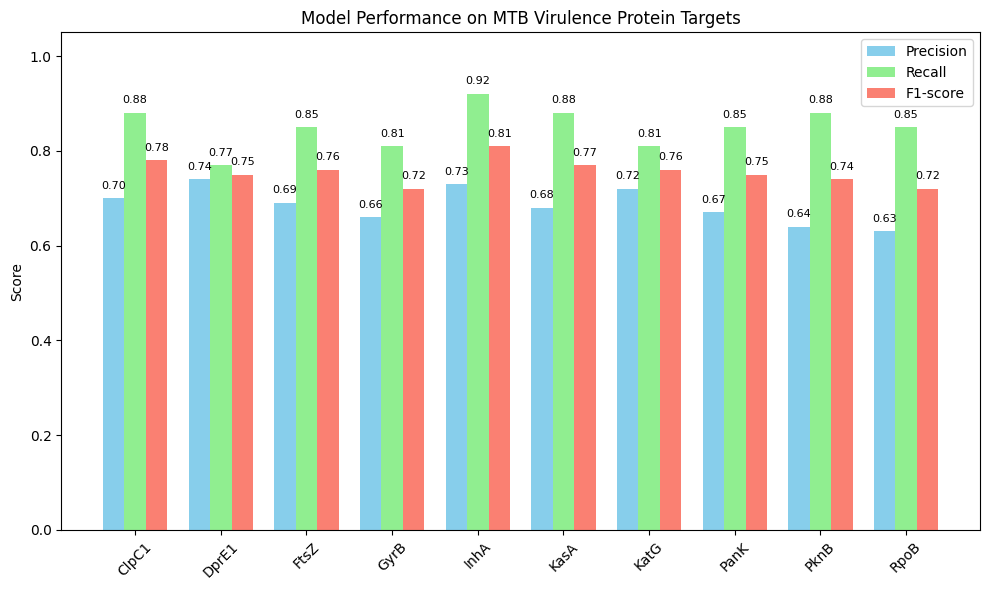

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Your target proteins
tasks = ['ClpC1', 'DprE1', 'FtsZ', 'GyrB', 'InhA', 'KasA', 'KatG', 'PanK', 'PknB', 'RpoB']

# Your reported metrics
precision = [0.70, 0.74, 0.69, 0.66, 0.73, 0.68, 0.72, 0.67, 0.64, 0.63]
recall =    [0.88, 0.77, 0.85, 0.81, 0.92, 0.88, 0.81, 0.85, 0.88, 0.85]
f1_score =  [0.78, 0.75, 0.76, 0.72, 0.81, 0.77, 0.76, 0.75, 0.74, 0.72]

# Plot settings
x = np.arange(len(tasks))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1_score, width, label='F1-score', color='salmon')

plt.xticks(x, tasks, rotation=45)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Performance on MTB Virulence Protein Targets")
plt.legend()

# Annotate each bar
for i in range(len(tasks)):
    for y, offset in zip([precision[i], recall[i], f1_score[i]], [-width, 0, width]):
        plt.text(i + offset, y + 0.02, f"{y:.2f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("mtb_model_performance_metrics.png", dpi=300)
plt.show()